  Country/Region  Confirmed  Deaths  Recovered  Active  New cases  New deaths  \
0    Afghanistan      36263    1269      25198    9796        106          10   
1        Albania       4880     144       2745    1991        117           6   
2        Algeria      27973    1163      18837    7973        616           8   
3        Andorra        907      52        803      52         10           0   
4         Angola        950      41        242     667         18           1   

   New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0             18                3.50                  69.49   
1             63                2.95                  56.25   
2            749                4.16                  67.34   
3              0                5.73                  88.53   
4              0                4.32                  25.47   

   Deaths / 100 Recovered  Confirmed last week  1 week change  \
0                    5.04                35526            737   
1   

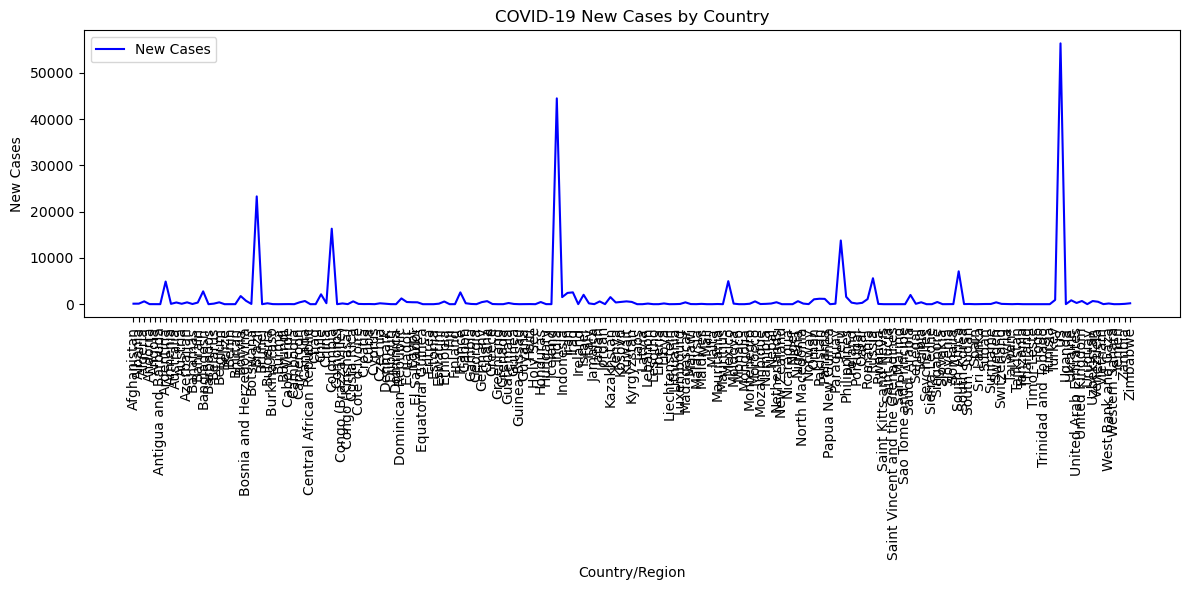

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("country_wise_latest.csv")

# Display basic info
print(data.head())
print(data.describe())

# Data Cleaning
data = data.dropna()

# Visualization
plt.figure(figsize=(12,6))
plt.plot(data["Country/Region"], data["New cases"], label="New Cases", color='blue')
plt.title("COVID-19 New Cases by Country")
plt.xlabel("Country/Region")
plt.ylabel("New Cases")
plt.xticks(rotation=90)  # Helps read country names on x-axis
plt.legend()
plt.tight_layout()       # Adjusts layout to prevent overlap
plt.show()

  Country/Region  Confirmed  Deaths  Recovered  Active  New cases  New deaths  \
0    Afghanistan      36263    1269      25198    9796        106          10   
1        Albania       4880     144       2745    1991        117           6   

   New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0             18                3.50                  69.49   
1             63                2.95                  56.25   

   Deaths / 100 Recovered  Confirmed last week  1 week change  \
0                    5.04                35526            737   
1                    5.25                 4171            709   

   1 week % increase             WHO Region  
0               2.07  Eastern Mediterranean  
1              17.00                 Europe  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region  

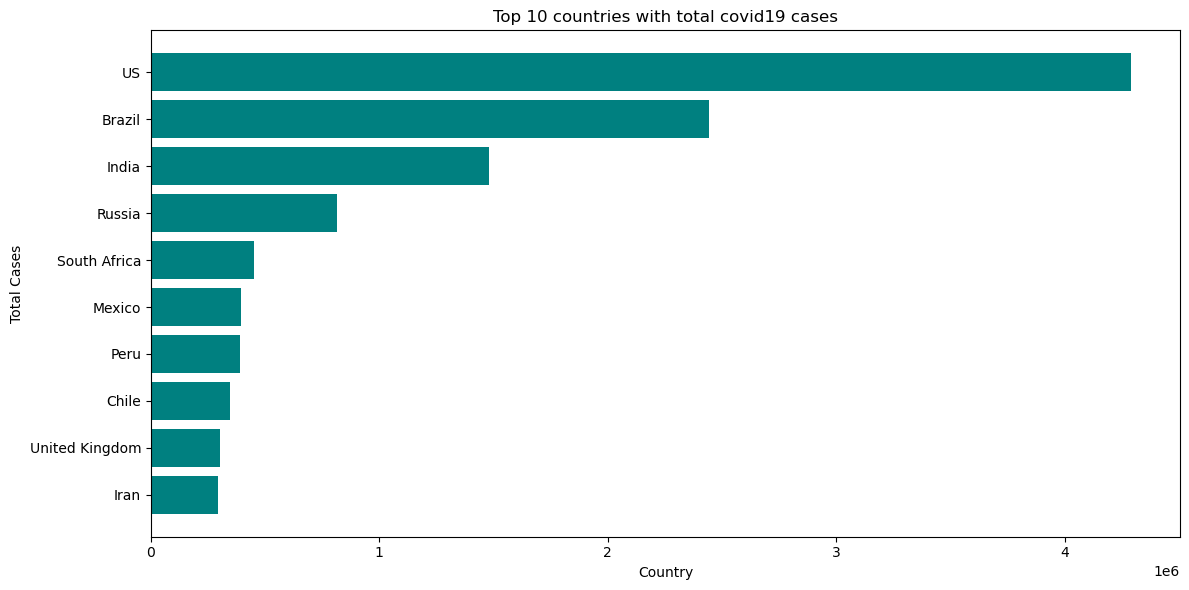

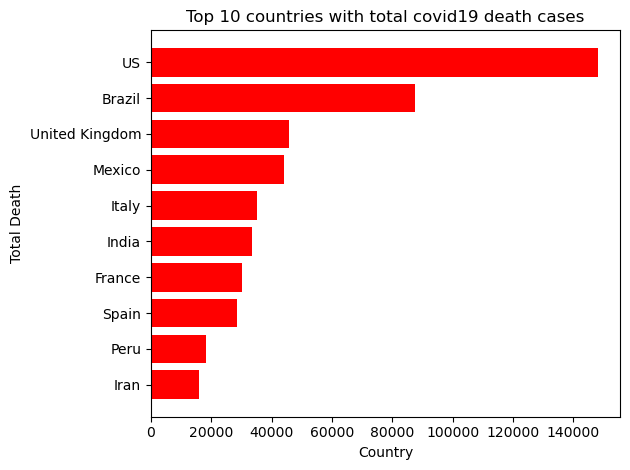

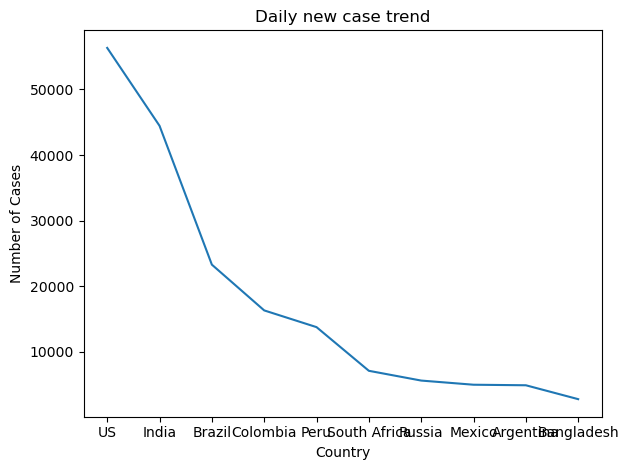

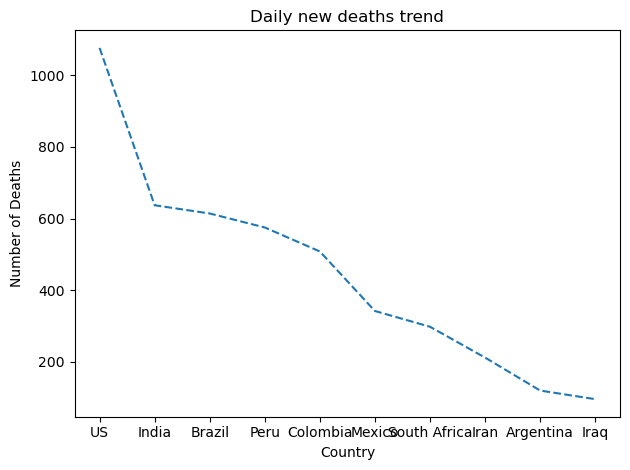

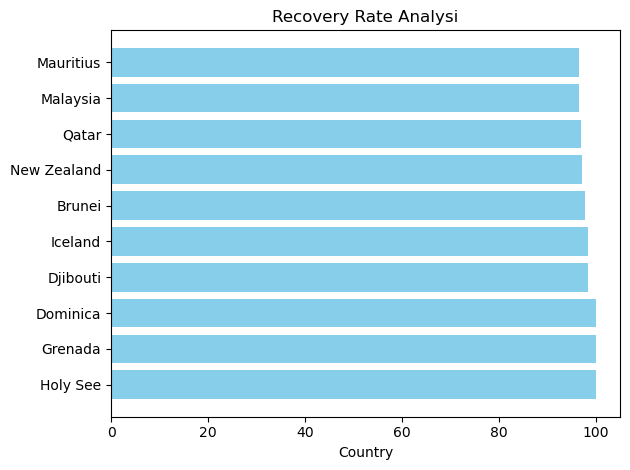

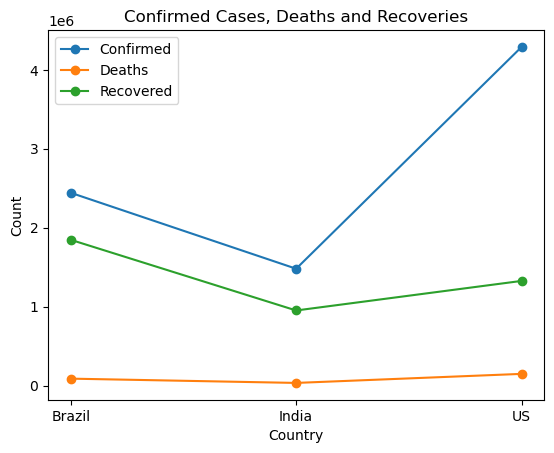

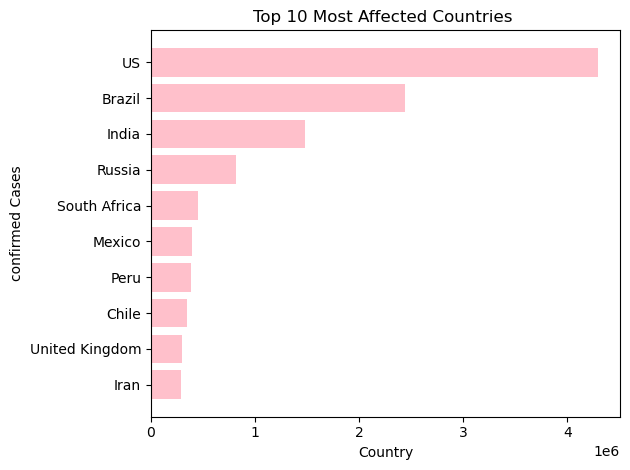

US


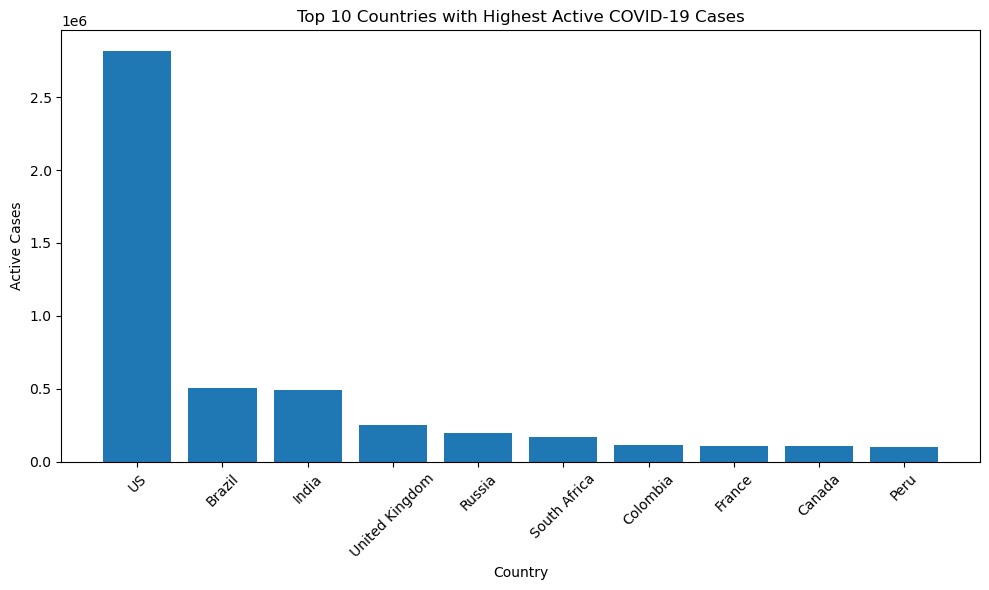

Country with highest active cases: US
Active cases: 2816444


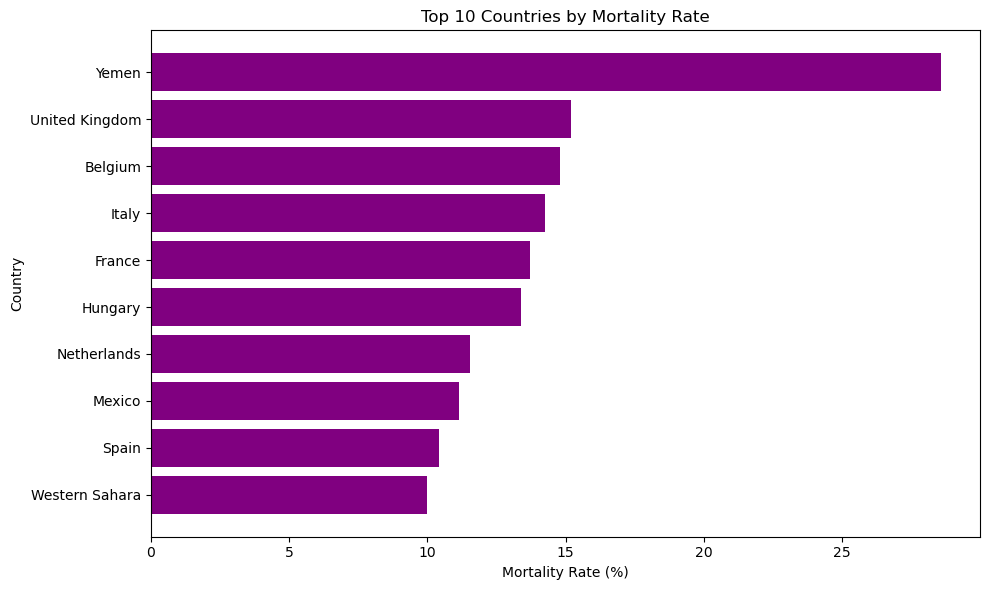

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#load dataset
data=pd.read_csv('country_wise_latest.csv')
print(data.head(2))
print(data.info())
print(data.describe())

# Data Cleaning
data = data.dropna()

# Visualization
plt.figure(figsize=(12,6))

#Total cases by country
country_cases=data.groupby('Country/Region')['Confirmed'].sum()
top10= country_cases.sort_values(ascending=False).head(10)

plt.barh(top10.index, top10.values, color='teal')
plt.title("Top 10 countries with total covid19 cases")
plt.xlabel('Country')
plt.ylabel('Total Cases')
plt.tight_layout()
plt.gca().invert_yaxis()
#plt.savefig('top10_countries.png')
plt.show()

#Total Deaths by Country
country_cases=data.groupby('Country/Region')['Deaths'].sum()
top10= country_cases.sort_values(ascending=False).head(10)

plt.barh(top10.index, top10.values, color='red')
plt.title("Top 10 countries with total covid19 death cases")
plt.xlabel('Country')
plt.ylabel('Total Death')
plt.tight_layout()
plt.gca().invert_yaxis()
#plt.savefig('top10_countries.png')
plt.show()

# New Cases Trend
new_cases=data.sort_values('New cases' ,ascending=False).head(10)


plt.plot(new_cases['Country/Region'],new_cases['New cases'])
plt.title("Daily new case trend")
plt.xlabel("Country")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()

#New death Trend
new_deaths=data.sort_values('New deaths' ,ascending=False).head(10)


plt.plot(new_deaths['Country/Region'],new_deaths['New deaths'] , linestyle ='--')
plt.title("Daily new deaths trend")
plt.xlabel("Country")
plt.ylabel("Number of Deaths")
plt.tight_layout()
plt.show()

#Recovery Rate Analysis
data['rating_rate']=(data['Recovered']/data['Confirmed'])*100
#rate=data.groupby('Country/Region')['rating_rate'].sum()

#s= rate.sort_values(ascending=False).head(10)
s= data.sort_values('rating_rate' ,ascending=False).head(10)

#plt.barh(s.index, s.values, color='skyblue')
plt.barh(s['Country/Region'], s['rating_rate'], color='skyblue')
plt.title("Recovery Rate Analysi")
plt.xlabel("Country")
plt.ylabel("")
plt.tight_layout()
plt.show()

#Compare INDIA,BRAZIL AND USA
countries=data[data['Country/Region'].isin(['India','US','Brazil'])]

plt.plot(countries['Country/Region'], countries['Confirmed'],
         marker='o', label='Confirmed')

plt.plot(countries['Country/Region'], countries['Deaths'],
         marker='o', label='Deaths')

plt.plot(countries['Country/Region'], countries['Recovered'],
         marker='o', label='Recovered')

plt.title('Confirmed Cases, Deaths and Recoveries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend()
#plt.grid(True)
plt.show()


#TOP 10 MOST Affected countries
top10= data.sort_values('Confirmed',ascending=False).head(10)

plt.barh(top10['Country/Region'], top10['Confirmed'], color='pink')
plt.title("Top 10 Most Affected Countries ")
plt.xlabel('Country')
plt.ylabel('confirmed Cases')
plt.tight_layout()
plt.gca().invert_yaxis()
#plt.savefig('top10_countries.png')
plt.show()
most_cases = data.loc[data['Confirmed'].idxmax(), 'Country/Region']
print(most_cases)


#Active Cases Analysis
top10 = data.sort_values(by='Active', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10['Country/Region'], top10['Active'])

plt.title('Top 10 Countries with Highest Active COVID-19 Cases')
plt.xlabel('Country')
plt.ylabel('Active Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
country = data.loc[data['Active'].idxmax(), 'Country/Region']
active_cases = data['Active'].max()

print("Country with highest active cases:", country)
print("Active cases:", active_cases)

#Mortality Rate Analysis
data['Mortality Rate'] = (data['Deaths'] / data['Confirmed']) * 100

top10 = data.sort_values(by='Mortality Rate', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Country/Region'], top10['Mortality Rate'] ,color='Purple')

plt.title('Top 10 Countries by Mortality Rate')
plt.xlabel('Mortality Rate (%)')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

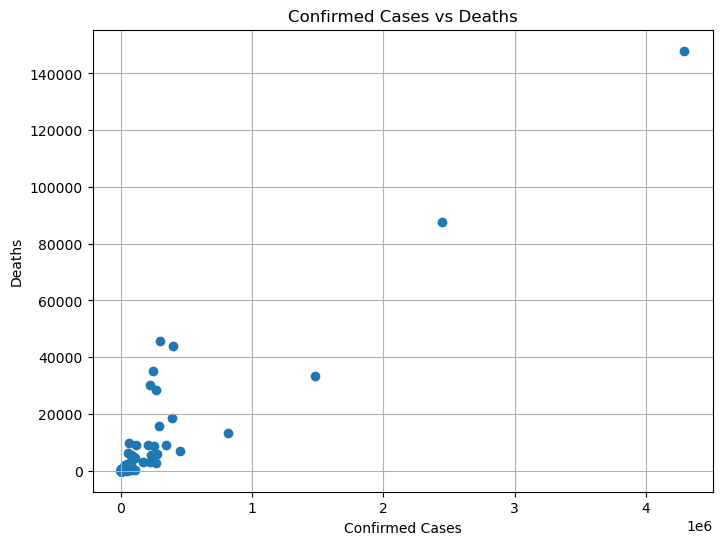

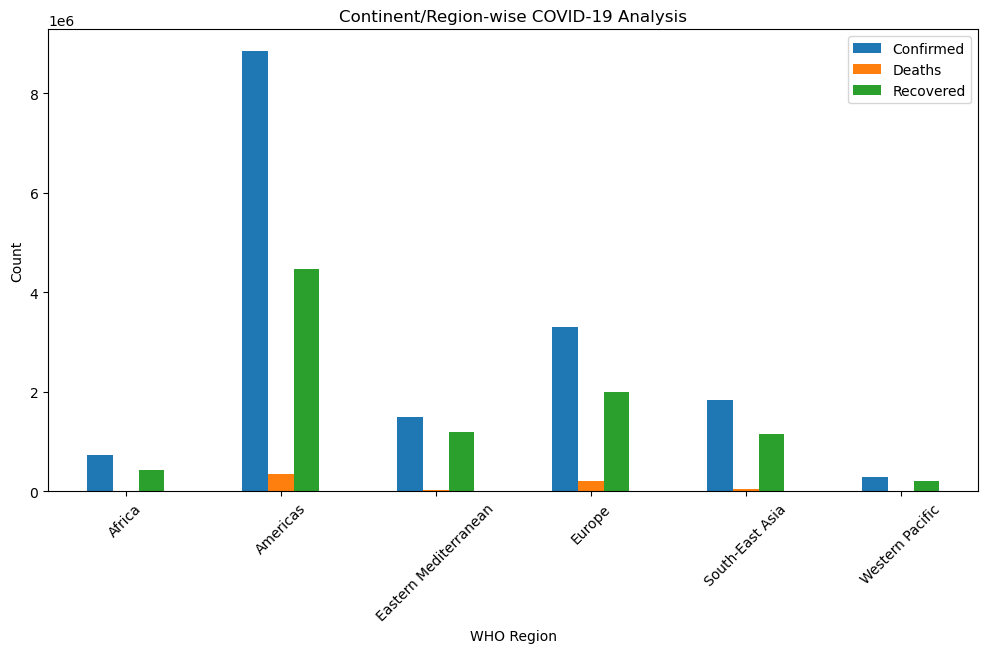

In [39]:
import matplotlib.pyplot as plt
#1. Correlation Analysis
##Create a scatter plot:
#X-axis → Confirmed Cases
#Y-axis → Deaths

plt.figure(figsize=(8,6))
plt.scatter(data['Confirmed'], data['Deaths'] )

plt.title('Confirmed Cases vs Deaths')
plt.xlabel('Confirmed Cases')
plt.ylabel('Deaths')
plt.grid(True)
plt.show()

#Continent-wise Analysis : compare confirmed .deaths,and recovery
region_data = data.groupby('WHO Region')[['Confirmed','Deaths','Recovered']].sum()

region_data.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Continent/Region-wise COVID-19 Analysis')
plt.xlabel('WHO Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

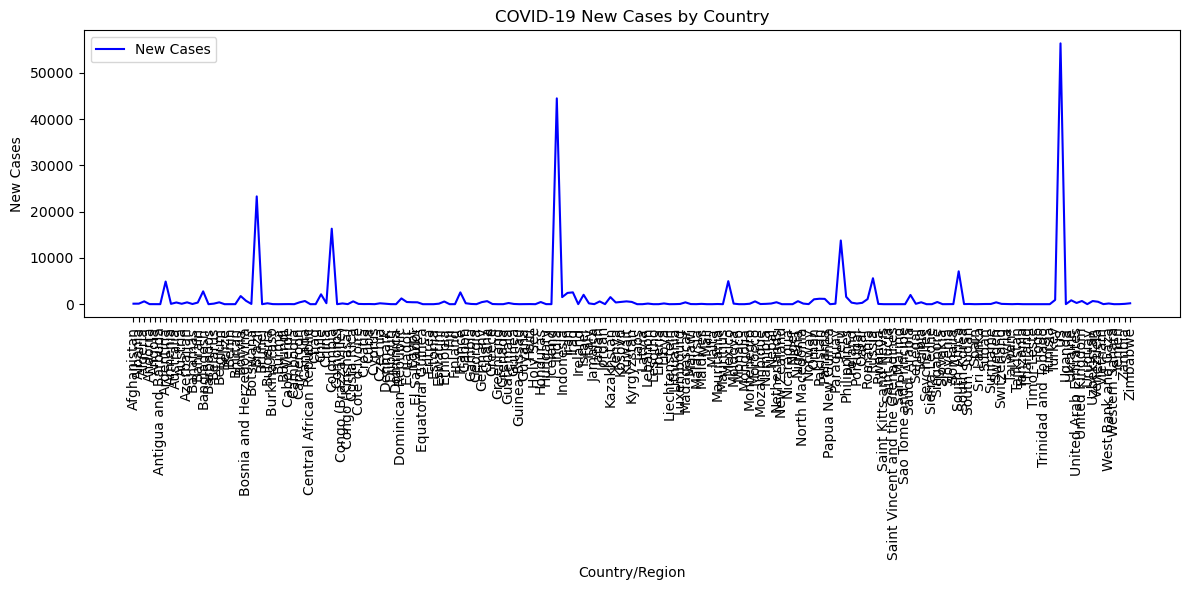

In [40]:
plt.figure(figsize=(12,6))
plt.plot(data["Country/Region"], data["New cases"], label="New Cases", color='blue')
plt.title("COVID-19 New Cases by Country")
plt.xlabel("Country/Region")
plt.ylabel("New Cases")
plt.xticks(rotation=90)  # Helps read country names on x-axis
plt.legend()
plt.tight_layout()       # Adjusts layout to prevent overlap
plt.show()

In [10]:
data.columns

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')